In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# Load the datasets
student_info = pd.read_csv("../data/studentInfo.csv")
student_assessment = pd.read_csv("../data/studentAssessment.csv")
student_vle = pd.read_csv("../data/studentVle.csv")
student_registration = pd.read_csv("../data/studentRegistration.csv")
courses = pd.read_csv("../data/courses.csv")
vle = pd.read_csv("../data/vle.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [7]:
# Display the shape of each dataset
print("Student Info:", student_info.shape)
print("Student Assessment:", student_assessment.shape)
print("Student VLE:", student_vle.shape)
print("Student Registration:", student_registration.shape)
print("Courses:", courses.shape)
print("VLE:", vle.shape)

Student Info: (32593, 12)
Student Assessment: (173912, 5)
Student VLE: (10655280, 6)
Student Registration: (32593, 5)
Courses: (22, 3)
VLE: (6364, 6)


In [8]:
# Feature 1: Total number of clicks made by each student.
# It represents the student's overall engagement with the online learning platform.

total_clicks = (
    student_vle.groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

# Renaming the column
total_clicks.rename(columns={"sum_click": "total_clicks"}, inplace=True)

# Displaying the first few rows and dataset size
print(total_clicks.head())
print(total_clicks.shape)

   id_student  total_clicks
0        6516          2791
1        8462           656
2       11391           934
3       23629           161
4       23698           910
(26074, 2)


In [9]:
# Feature 2: Average assessment score for each student.
# It represents the student's overall academic performance.

avg_score = (
    student_assessment.groupby("id_student")["score"]
    .mean()
    .reset_index()
)

# Rename the column
avg_score.rename(columns={"score": "average_score"}, inplace=True)

# Displaying the results
print(avg_score.head())
print(avg_score.shape)

   id_student  average_score
0        6516      61.800000
1        8462      87.000000
2       11391      82.000000
3       23629      82.500000
4       23698      74.444444
(23369, 2)


In [10]:
# Feature 3: Counting the number of assessments attempted by each student.
# It indicates how actively a student participated in assessments.

assessment_count = (
    student_assessment.groupby("id_student")
    .size()
    .reset_index(name="assessment_count")
)

# Displaying the results
print(assessment_count.head())
print(assessment_count.shape)

   id_student  assessment_count
0        6516                 5
1        8462                 7
2       11391                 5
3       23629                 4
4       23698                 9
(23369, 2)


In [11]:
# Feature 4: Creating a week column from the date.
# Dividing the day value by 7 groups activity into weekly intervals.

student_vle["week"] = student_vle["date"] // 7

# Calculate the total clicks for each student every week.
weekly_activity = (
    student_vle.groupby(["id_student", "week"])["sum_click"]
    .sum()
    .reset_index()
)

# Displaying the results
print(weekly_activity.head())
print(weekly_activity.shape)

   id_student  week  sum_click
0        6516    -4        110
1        6516    -3         48
2        6516    -2          2
3        6516    -1         96
4        6516     0        229
(584911, 3)


In [12]:
# Feature 5: Count the number of weeks in which each student was active.
# It measures learning consistency over the course duration.

active_weeks = (
    weekly_activity.groupby("id_student")["week"]
    .nunique()
    .reset_index(name="active_weeks")
)

# Displaying the results
print(active_weeks.head())
print(active_weeks.shape)

   id_student  active_weeks
0        6516            39
1        8462            17
2       11391            27
3       23629            11
4       23698            27
(26074, 2)


In [13]:
# Step 5: Merging all the derived features into one dataset.
# Starting with the student_info and then adding the features created earlier.

merged = student_info.merge(total_clicks, on="id_student", how="left")
merged = merged.merge(avg_score, on="id_student", how="left")
merged = merged.merge(assessment_count, on="id_student", how="left")
merged = merged.merge(active_weeks, on="id_student", how="left")

# Replace missing values with 0.
# Missing values indicate that the student had no activity or assessments.

merged.fillna(0, inplace=True)

# Displaying the shape and first few rows of the merged dataset.
print("Merged Dataset Shape:", merged.shape)
print(merged.head())

Merged Dataset Shape: (32593, 16)
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  total_clicks  average_score  \
0              240       

In [14]:
# Step 6: Check for missing values in the merged dataset.
# This helps identify any incomplete data before training the model.

print(merged.isnull().sum())

code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
total_clicks            0
average_score           0
assessment_count        0
active_weeks            0
dtype: int64


In [15]:
# Checking the data type of each categorical column

categorical_columns = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "code_module",
    "code_presentation",
    "final_result"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(merged[column].apply(type).value_counts())


gender
gender
<class 'str'>    32593
Name: count, dtype: int64

region
region
<class 'str'>    32593
Name: count, dtype: int64

highest_education
highest_education
<class 'str'>    32593
Name: count, dtype: int64

imd_band
imd_band
<class 'str'>    31482
<class 'int'>     1111
Name: count, dtype: int64

age_band
age_band
<class 'str'>    32593
Name: count, dtype: int64

disability
disability
<class 'str'>    32593
Name: count, dtype: int64

code_module
code_module
<class 'str'>    32593
Name: count, dtype: int64

code_presentation
code_presentation
<class 'str'>    32593
Name: count, dtype: int64

final_result
final_result
<class 'str'>    32593
Name: count, dtype: int64


In [16]:
# Step 7: Converting all categorical values to strings before encoding

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "code_module",
    "code_presentation",
    "final_result"
]

for column in categorical_columns:
    merged[column] = merged[column].astype(str)   # Convert everything to text
    merged[column] = encoder.fit_transform(merged[column])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


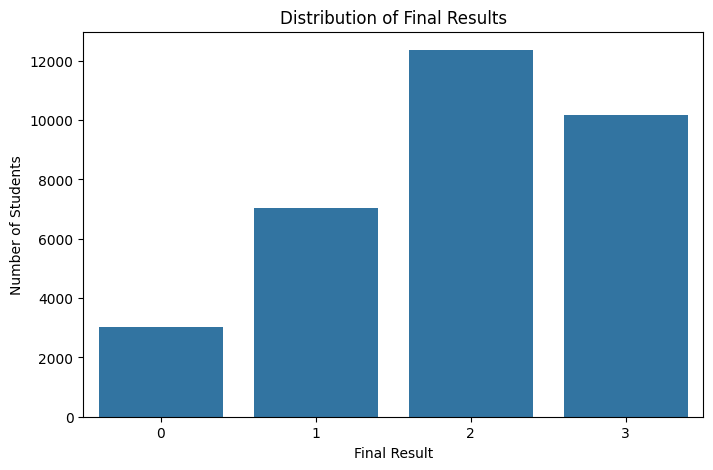

In [17]:
# Visualize the distribution of student's final results.
# This graph shows how many students fall into each outcome category.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x="final_result", data=merged)
plt.title("Distribution of Final Results")
plt.xlabel("Final Result")
plt.ylabel("Number of Students")
plt.show()

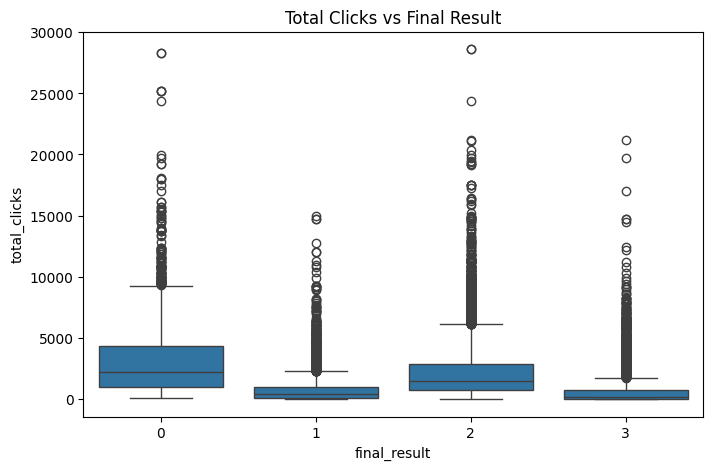

In [18]:
# Comparing the student's engagement (total clicks) across different final results.

plt.figure(figsize=(8,5))
sns.boxplot(x="final_result", y="total_clicks", data=merged)
plt.title("Total Clicks vs Final Result")
plt.show()

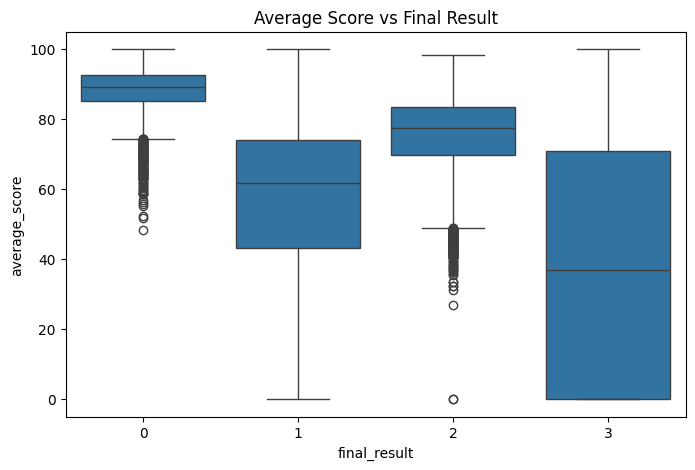

In [19]:
# Compare average assessment scores for different final results.

plt.figure(figsize=(8,5))
sns.boxplot(x="final_result", y="average_score", data=merged)
plt.title("Average Score vs Final Result")
plt.show()

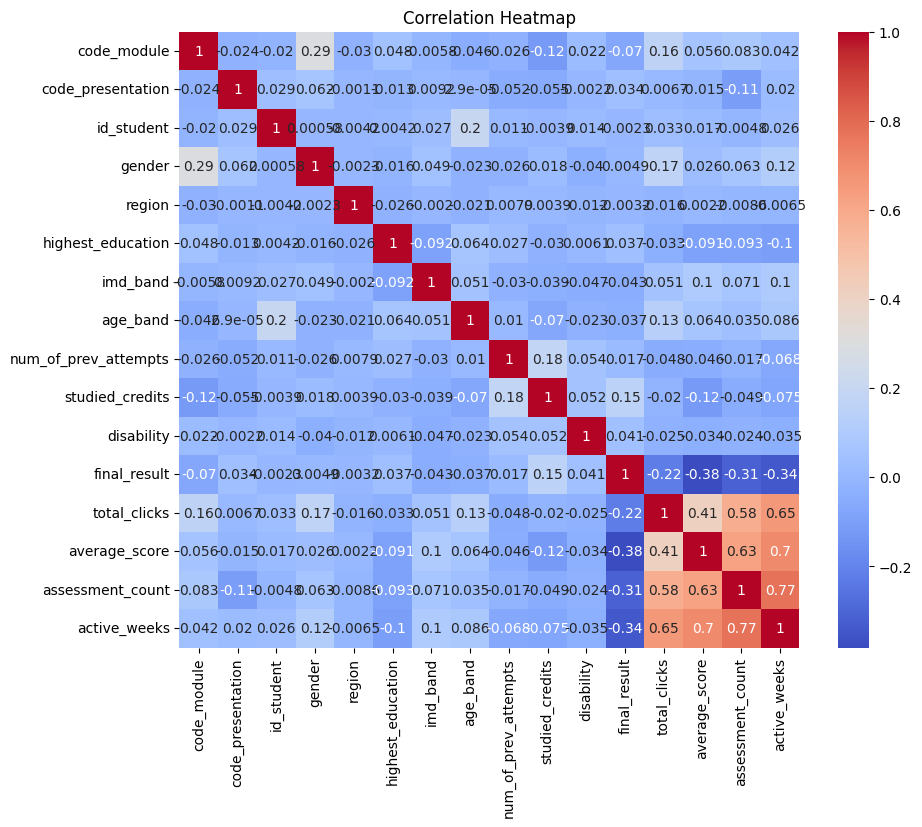

In [20]:
# Displaying the correlation between numerical features.

plt.figure(figsize=(10,8))

sns.heatmap(
    merged.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
#1. Distribution of Final Results Graph
#The graph shows that most students belong to the Pass and Distinction categories, while Fail has the fewest students. This indicates that the dataset is slightly imbalanced, with successful outcomes occurring more frequently than failures.

#2. Total Clicks vs Final Result Graph
#The box plot shows that students with higher learning platform activity generally achieve better academic results. However, the presence of several outliers indicates that engagement alone does not completely determine the final outcome.

#3. Average Score vs Final Result Graph
#Students with higher average assessment scores tend to achieve better final results, showing a strong relationship between assessment performance and academic success. Some variation within each category suggests that other factors also influence the final result.

#4. Correlation Heatmap Graph
#The heatmap indicates that average_score, assessment_count, active_weeks, and total_clicks have the strongest relationships with student performance. These features are likely to be the most important predictors in the machine learning model.

In [22]:
# Saving the processed dataset for machine learning.

merged.to_csv(
    "../outputs/cleaned_data/student_ml_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [23]:
# Select input features (X) and target variable (y)

# X contains the features used to predict the student's final result.
X = merged.drop(columns=["id_student", "final_result"])

# y is the target variable to be predicted.
y = merged["final_result"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (32593, 14)
Target Shape: (32593,)


In [24]:
# Splitting the data into training and testing sets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

# Note: 80% of the data is used for training the model, while 20% is reserved for testing its performance.

Training Set: (26074, 14)
Testing Set: (6519, 14)


In [25]:
# Training a Random Forest Classifier
# It learns patterns from student engagement and performance features
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
# Predicting the final result for the test data.

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [27]:
# Evaluate the performance of the model.
# Accuracy, classification report, and confusion matrix are used to measure how well the model predicts student outcomes.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.684767602393005

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.46      0.53       593
           1       0.57      0.37      0.45      1495
           2       0.71      0.89      0.79      2458
           3       0.71      0.74      0.73      1973

    accuracy                           0.68      6519
   macro avg       0.65      0.61      0.62      6519
weighted avg       0.67      0.68      0.67      6519


Confusion Matrix:
[[ 275    1  315    2]
 [   1  548  391  555]
 [ 150   92 2182   34]
 [  21  323  170 1459]]


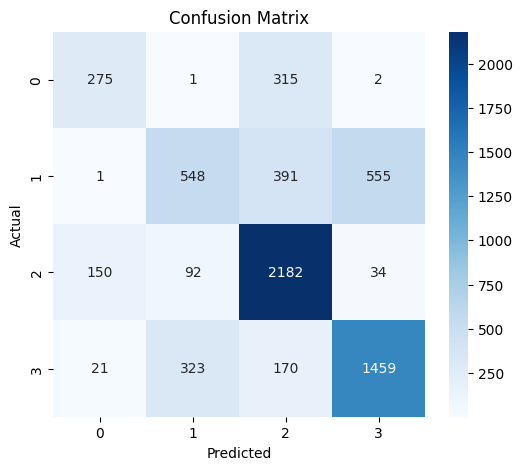

In [28]:
# The confusion matrix visualizes the model's prediction performance by comparing actual and predicted classes.
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

                 Feature  Importance
11         average_score    0.186325
12      assessment_count    0.169321
13          active_weeks    0.152503
10          total_clicks    0.135189
3                 region    0.070054
5               imd_band    0.065401
0            code_module    0.055558
8        studied_credits    0.039517
1      code_presentation    0.039367
4      highest_education    0.028474
6               age_band    0.018012
2                 gender    0.015445
7   num_of_prev_attempts    0.014752
9             disability    0.010083


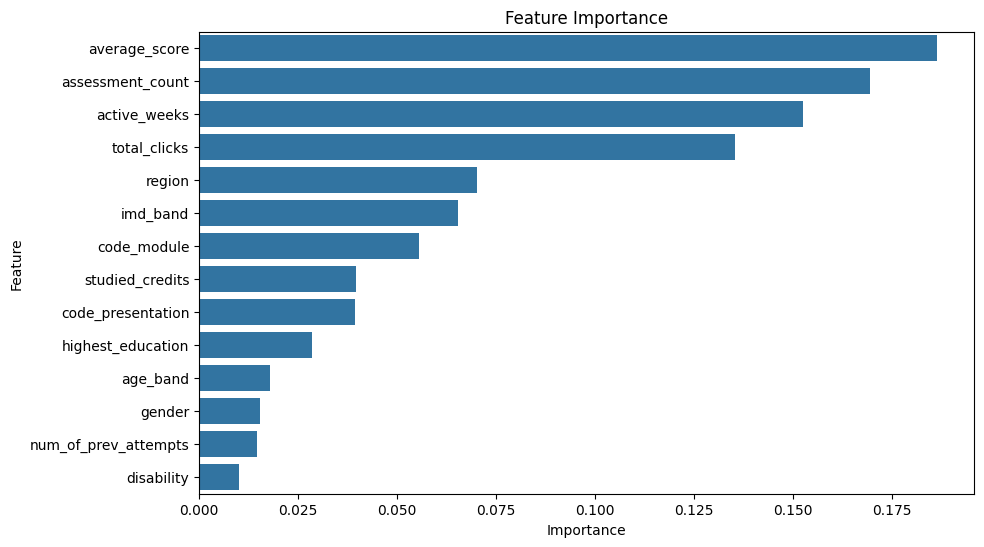

In [29]:
# Displaying feature importance
# It identifies which variables contribute the most to predicting student performance.

feature_importance = model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": feature_importance
    })
    .sort_values(by="Importance", ascending=False)
)

print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x="Importance", y="Feature")

plt.title("Feature Importance")
plt.show()

In [30]:
# The trained Random Forest model is saved so it can be reused without retraining.
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [31]:
# Training a Decision Tree Classifier
# It makes predictions using a tree like decision structure
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6048473692284093


In [32]:
# Training a Logistic Regression model
# This compares its performance with more complex features
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6089891087590121


c:\Users\user\OneDrive\Desktop\Future_Readiness_Project\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
# Training a K-Nearest Neighbors (KNN) Classifier
# It predicts the final result based on the closest training examples in the feature space

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.5787697499616505


In [34]:
# Training a Support Vector Machine (SVM) Classifier
# It finds the optimal hyperplane that separates different classes in the feature space

from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.5479368001227182


In [35]:
# Save Random Forest model
joblib.dump(model, "../models/random_forest_model.pkl")

# Save Decision Tree model
joblib.dump(dt, "../models/decision_tree_model.pkl")

# Save Logistic Regression model
joblib.dump(lr, "../models/logistic_regression_model.pkl")

# Save KNN model
joblib.dump(knn, "../models/knn_model.pkl")

# Save SVM model
joblib.dump(svm, "../models/svm_model.pkl")

print("All models saved successfully!")

All models saved successfully!


In [36]:
# ==========================================
# AI Learning Resilience Score
# ==========================================

In [37]:
# Import libraries required for AI Resilience Score calculation and visualization.
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Using the features representing academic performance and learning engagement.
features = [
    "average_score",
    "total_clicks",
    "active_weeks",
    "assessment_count"
]

resilience = merged[features].copy()

In [39]:
# Normalize all selected features to a common scale (0–1)
scaler = MinMaxScaler()

resilience[features] = scaler.fit_transform(resilience[features])

In [40]:
# Calculating the AI Learning Resilience Score using weighted features
resilience["AI_Resilience_Score"] = (
      0.40 * resilience["average_score"]
    + 0.25 * resilience["active_weeks"]
    + 0.20 * resilience["total_clicks"]
    + 0.15 * resilience["assessment_count"]
) * 100 

# 40% Average Score → Academic performance is given the highest importance.
# 25% Active Weeks → Students who learn consistently are considered more resilient.
# 20% Total Clicks → Higher engagement with the learning platform indicates active participation.
# 15% Assessment Count → Completing more assessments shows commitment to learning.

In [41]:
# Adding resilience score to the main dataset
merged["AI_Resilience_Score"] = resilience["AI_Resilience_Score"]

In [55]:
# Classifying students into different resilience categories.
def resilience_level(score):

    if score >= 80:
        return "High"

    elif score >= 60:
        return "Moderate"

    elif score >= 40:
        return "Low"

    else:
        return "Very Low"

merged["Resilience_Level"] = merged["AI_Resilience_Score"].apply(resilience_level)

In [64]:
def intervention(level):

    if level == "High":
        return "Advanced AI courses and research opportunities"

    elif level == "Moderate":
        return "AI skill workshops and regular practice"

    elif level == "Low":
        return "Mentoring and personalized study plan"

    else:
        return "Immediate counseling and academic support"

merged["Recommended_Intervention"] = merged["Resilience_Level"].apply(intervention)

In [65]:
merged[[
    "AI_Resilience_Score",
    "Resilience_Level",
    "Recommended_Intervention"
]].head(10)

,AI_Resilience_Score,Resilience_Level,Recommended_Intervention
0,51.829050,Low,Mentoring and personalized study plan
1,50.008984,Low,Mentoring and personalized study plan
2,2.521982,Very Low,Immediate counseling and academic support
3,56.679895,Low,Mentoring and personalized study plan
4,43.184525,Low,Mentoring and personalized study plan
5,55.424675,Low,Mentoring and personalized study plan
6,50.688823,Low,Mentoring and personalized study plan
7,54.148277,Low,Mentoring and personalized study plan
8,53.492585,Low,Mentoring and personalized study plan
9,57.597433,Low,Mentoring and personalized study plan


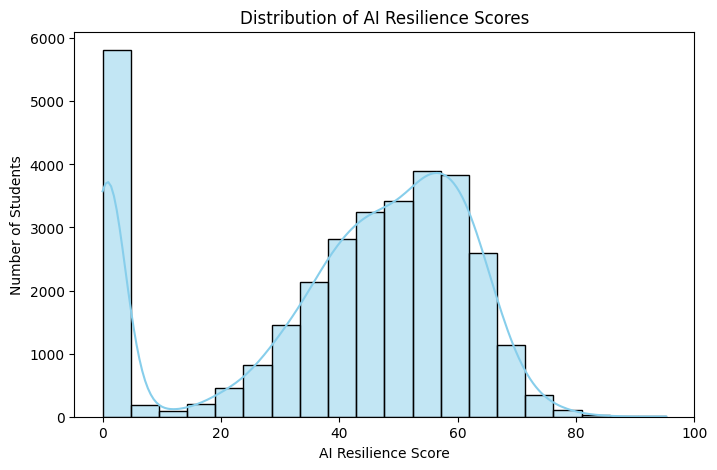

In [66]:
# Plotting the distribution of AI Resilience Scores

plt.figure(figsize=(8,5))

# Creating histogram with density curve
sns.histplot(
    merged["AI_Resilience_Score"],
    bins=20,
    kde=True,
    color="skyblue"
)

# Adding chart title and axis labels
plt.title("Distribution of AI Resilience Scores")
plt.xlabel("AI Resilience Score")
plt.ylabel("Number of Students")

# Display the plot
plt.show()

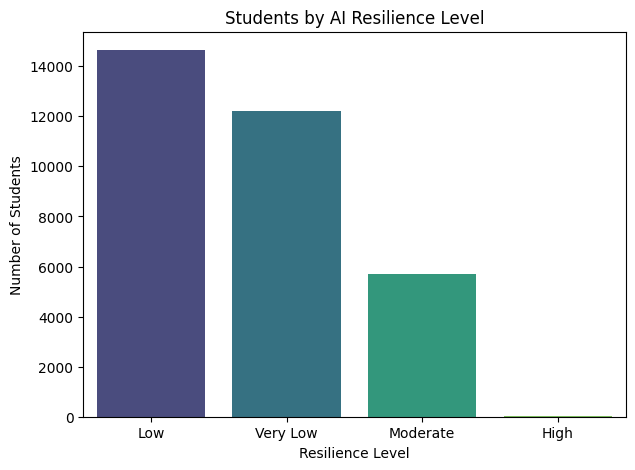

In [67]:
# Plotting the number of students in each resilience category

plt.figure(figsize=(7,5))

# Create count plot for resilience levels
sns.countplot(
    x="Resilience_Level",
    hue="Resilience_Level",
    data=merged,
    palette="viridis",
    legend=False
)

# Adding chart title and axis labels
plt.title("Students by AI Resilience Level")
plt.xlabel("Resilience Level")
plt.ylabel("Number of Students")

# Display the plot
plt.show()

In [68]:
# Counting students in each resilience level
print(merged["Resilience_Level"].value_counts())

Resilience_Level
Low         14647
Very Low    12206
Moderate     5698
High           42
Name: count, dtype: int64


In [69]:
# Sort students by highest AI Resilience Score

top_students = merged.sort_values(
    by="AI_Resilience_Score",
    ascending=False
)

# Display the top 10 resilient students
top_students[[
    "id_student",
    "AI_Resilience_Score",
    "Resilience_Level",
    "Recommended_Intervention"
]].head(10)

,id_student,AI_Resilience_Score,Resilience_Level,Recommended_Intervention
28145,537811,95.250264,High,Advanced AI courses and research opportunities
11225,537811,95.250264,High,Advanced AI courses and research opportunities
15158,537811,95.250264,High,Advanced AI courses and research opportunities
12029,630905,93.956612,High,Advanced AI courses and research opportunities
28535,630905,93.956612,High,Advanced AI courses and research opportunities
11915,622374,86.835059,High,Advanced AI courses and research opportunities
27102,622374,86.835059,High,Advanced AI courses and research opportunities
29345,680027,85.748521,High,Advanced AI courses and research opportunities
12539,680027,85.748521,High,Advanced AI courses and research opportunities
25906,609229,85.011181,High,Advanced AI courses and research opportunities


In [70]:
# Sort students by lowest AI Resilience Score

bottom_students = merged.sort_values(
    by="AI_Resilience_Score",
    ascending=True
)

# Display the bottom 10 students requiring support
bottom_students[[
    "id_student",
    "AI_Resilience_Score",
    "Resilience_Level",
    "Recommended_Intervention"
]].head(10)

,id_student,AI_Resilience_Score,Resilience_Level,Recommended_Intervention
19823,573244,0.0,Very Low,Immediate counseling and academic support
2842,398315,0.0,Very Low,Immediate counseling and academic support
26480,480531,0.0,Very Low,Immediate counseling and academic support
2846,401319,0.0,Very Low,Immediate counseling and academic support
11514,582340,0.0,Very Low,Immediate counseling and academic support
26484,483195,0.0,Very Low,Immediate counseling and academic support
26489,484292,0.0,Very Low,Immediate counseling and academic support
2852,408106,0.0,Very Low,Immediate counseling and academic support
26523,503024,0.0,Very Low,Immediate counseling and academic support
26531,505900,0.0,Very Low,Immediate counseling and academic support


In [71]:
# Saving the final dataset with AI Resilience Score and intervention details

merged.to_csv(
    "../outputs/student_ai_resilience.csv",
    index=False
)

# Display confirmation message
print("AI Resilience dataset saved successfully!")

AI Resilience dataset saved successfully!


In [ ]:
# ==========================================
# Academic Pressure Score
# ==========================================

In [72]:
# -----------------------------------------------
# Normalize Features
# -----------------------------------------------

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

merged[['studied_credits_norm',
        'assessment_count_norm',
        'prev_attempts_norm']] = scaler.fit_transform(

    merged[['studied_credits',
            'assessment_count',
            'num_of_prev_attempts']]
)

# -----------------------------------------------
# Calculate Academic Pressure Score
# -----------------------------------------------

merged["Academic_Pressure_Score"] = (
      0.50 * merged["studied_credits_norm"]
    + 0.30 * merged["assessment_count_norm"]
    + 0.20 * merged["prev_attempts_norm"]
) * 100

In [73]:
# -----------------------------------------------
# Pressure Category
# -----------------------------------------------

def pressure_category(score):

    if score <= 25:
        return "Low"

    elif score <= 50:
        return "Moderate"

    elif score <= 75:
        return "High"

    else:
        return "Very High"

merged["Pressure_Level"] = merged["Academic_Pressure_Score"].apply(pressure_category)

In [74]:
# -----------------------------------------------
# Personalized Intervention
# -----------------------------------------------

def pressure_feedback(row):

    contributions = {
        "Studied Credits": row["studied_credits_norm"] * 0.50,
        "Assessment Count": row["assessment_count_norm"] * 0.30,
        "Previous Attempts": row["prev_attempts_norm"] * 0.20
    }

    dominant = max(contributions, key=contributions.get)

    level = row["Pressure_Level"]

    if dominant == "Studied Credits":

        if level == "Very High":
            return ("Very High Pressure",
                    "Heavy course workload detected.",
                    "Reduce workload if possible, prioritize subjects, meet your academic advisor and follow a structured study schedule.")

        elif level == "High":
            return ("High Pressure",
                    "Course workload is the major contributor.",
                    "Improve time management and divide study hours across subjects.")

        else:
            return (level,
                    "Course workload is manageable.",
                    "Maintain your study schedule.")

    elif dominant == "Assessment Count":

        if level == "Very High":
            return ("Very High Pressure",
                    "Too many assessments are creating pressure.",
                    "Prepare a weekly assessment calendar, start assignments early and seek faculty guidance.")

        elif level == "High":
            return ("High Pressure",
                    "Assessment load is high.",
                    "Break assignments into smaller tasks and avoid last-minute preparation.")

        else:
            return (level,
                    "Assessment load is manageable.",
                    "Continue your regular preparation.")

    else:

        if level == "Very High":
            return ("Very High Pressure",
                    "Previous academic attempts indicate recurring learning difficulties.",
                    "Attend mentoring sessions, revise weak topics and seek academic support immediately.")

        elif level == "High":
            return ("High Pressure",
                    "Past academic performance is contributing to current pressure.",
                    "Review previous mistakes and attend extra learning sessions.")

        else:
            return (level,
                    "Previous attempts have minimal impact.",
                    "Continue monitoring your academic progress.")

In [75]:
merged[["Pressure_Level_Final",
        "Pressure_Reason",
        "Pressure_Intervention"]] = merged.apply(
            pressure_feedback,
            axis=1,
            result_type="expand"
        )

In [76]:
merged.to_csv("Student_Performance_With_Pressure.csv", index=False)

print("Academic Pressure Analysis Completed Successfully!")

Academic Pressure Analysis Completed Successfully!


In [77]:
df = pd.read_csv("Student_Performance_With_Pressure.csv")

In [78]:
df.head(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,Resilience_Level,Recommended_Intervention,studied_credits_norm,assessment_count_norm,prev_attempts_norm,Academic_Pressure_Score,Pressure_Level,Pressure_Level_Final,Pressure_Reason,Pressure_Intervention
0,0,1,11391,1,0,1,10,2,0,240,...,Low,Mentoring and personalized study plan,0.336,0.178571,0.0,22.157143,Low,Low,Course workload is manageable.,Maintain your study schedule.
1,0,1,28400,0,6,1,3,1,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
2,0,1,30268,0,5,0,4,1,0,60,...,Very Low,Immediate counseling and academic support,0.048,0.000000,0.0,2.400000,Low,Low,Course workload is manageable.,Maintain your study schedule.
3,0,1,31604,0,7,0,6,1,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
4,0,1,32885,0,11,2,6,0,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
5,0,1,38053,1,10,0,9,1,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
6,0,1,45462,1,6,1,4,0,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
7,0,1,45642,0,5,0,10,0,0,120,...,Low,Mentoring and personalized study plan,0.144,0.178571,0.0,12.557143,Low,Low,Course workload is manageable.,Maintain your study schedule.
8,0,1,52130,0,0,0,8,0,0,90,...,Low,Mentoring and personalized study plan,0.096,0.178571,0.0,10.157143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
9,0,1,53025,1,4,4,0,2,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.


In [87]:
# No of rows and columns in the final dataset
merged.shape

(32593, 27)

In [89]:
#First 10 rows of the final dataset
merged.head(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,Resilience_Level,Recommended_Intervention,studied_credits_norm,assessment_count_norm,prev_attempts_norm,Academic_Pressure_Score,Pressure_Level,Pressure_Level_Final,Pressure_Reason,Pressure_Intervention
0,0,1,11391,1,0,1,10,2,0,240,...,Low,Mentoring and personalized study plan,0.336,0.178571,0.0,22.157143,Low,Low,Course workload is manageable.,Maintain your study schedule.
1,0,1,28400,0,6,1,3,1,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
2,0,1,30268,0,5,0,4,1,0,60,...,Very Low,Immediate counseling and academic support,0.048,0.000000,0.0,2.400000,Low,Low,Course workload is manageable.,Maintain your study schedule.
3,0,1,31604,0,7,0,6,1,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
4,0,1,32885,0,11,2,6,0,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
5,0,1,38053,1,10,0,9,1,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
6,0,1,45462,1,6,1,4,0,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
7,0,1,45642,0,5,0,10,0,0,120,...,Low,Mentoring and personalized study plan,0.144,0.178571,0.0,12.557143,Low,Low,Course workload is manageable.,Maintain your study schedule.
8,0,1,52130,0,0,0,8,0,0,90,...,Low,Mentoring and personalized study plan,0.096,0.178571,0.0,10.157143,Low,Low,Assessment load is manageable.,Continue your regular preparation.
9,0,1,53025,1,4,4,0,2,0,60,...,Low,Mentoring and personalized study plan,0.048,0.178571,0.0,7.757143,Low,Low,Assessment load is manageable.,Continue your regular preparation.


In [90]:
#Last 10 rows of the final dataset
merged.tail(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,Resilience_Level,Recommended_Intervention,studied_credits_norm,assessment_count_norm,prev_attempts_norm,Academic_Pressure_Score,Pressure_Level,Pressure_Level_Final,Pressure_Reason,Pressure_Intervention
32583,6,3,2508153,0,1,2,2,0,0,30,...,Low,Mentoring and personalized study plan,0.0,0.321429,0.0,9.642857,Low,Low,Assessment load is manageable.,Continue your regular preparation.
32584,6,3,2533195,0,7,2,2,0,0,30,...,Low,Mentoring and personalized study plan,0.0,0.321429,0.0,9.642857,Low,Low,Assessment load is manageable.,Continue your regular preparation.
32585,6,3,2606765,0,3,2,9,0,0,30,...,Low,Mentoring and personalized study plan,0.0,0.321429,0.0,9.642857,Low,Low,Assessment load is manageable.,Continue your regular preparation.
32586,6,3,2608143,1,1,1,7,1,0,30,...,Very Low,Immediate counseling and academic support,0.0,0.000000,0.0,0.000000,Low,Low,Course workload is manageable.,Maintain your study schedule.
32587,6,3,2620947,0,6,0,9,0,0,30,...,Low,Mentoring and personalized study plan,0.0,0.321429,0.0,9.642857,Low,Low,Assessment load is manageable.,Continue your regular preparation.
32588,6,3,2640965,0,10,2,2,0,0,30,...,Very Low,Immediate counseling and academic support,0.0,0.000000,0.0,0.000000,Low,Low,Course workload is manageable.,Maintain your study schedule.
32589,6,3,2645731,0,0,2,5,1,0,30,...,Low,Mentoring and personalized study plan,0.0,0.321429,0.0,9.642857,Low,Low,Assessment load is manageable.,Continue your regular preparation.
32590,6,3,2648187,0,8,0,3,0,0,30,...,Low,Mentoring and personalized study plan,0.0,0.321429,0.0,9.642857,Low,Low,Assessment load is manageable.,Continue your regular preparation.
32591,6,3,2679821,0,7,2,10,1,0,30,...,Low,Mentoring and personalized study plan,0.0,0.071429,0.0,2.142857,Low,Low,Assessment load is manageable.,Continue your regular preparation.
32592,6,3,2684003,0,12,1,6,1,0,30,...,Low,Mentoring and personalized study plan,0.0,0.250000,0.0,7.500000,Low,Low,Assessment load is manageable.,Continue your regular preparation.


In [91]:
# View all columns in the final dataset
merged.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'total_clicks',
       'average_score', 'assessment_count', 'active_weeks',
       'AI_Resilience_Score', 'Resilience_Level', 'Recommended_Intervention',
       'studied_credits_norm', 'assessment_count_norm', 'prev_attempts_norm',
       'Academic_Pressure_Score', 'Pressure_Level', 'Pressure_Level_Final',
       'Pressure_Reason', 'Pressure_Intervention'],
      dtype='object')

In [92]:
#Data types and missing values in the final dataset
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               32593 non-null  int32  
 1   code_presentation         32593 non-null  int32  
 2   id_student                32593 non-null  int64  
 3   gender                    32593 non-null  int32  
 4   region                    32593 non-null  int32  
 5   highest_education         32593 non-null  int32  
 6   imd_band                  32593 non-null  int32  
 7   age_band                  32593 non-null  int32  
 8   num_of_prev_attempts      32593 non-null  int64  
 9   studied_credits           32593 non-null  int64  
 10  disability                32593 non-null  int32  
 11  final_result              32593 non-null  int32  
 12  total_clicks              32593 non-null  float64
 13  average_score             32593 non-null  float64
 14  assess

In [93]:
# Missing values in the final dataset
merged.isnull().sum()

code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                    0
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
total_clicks                0
average_score               0
assessment_count            0
active_weeks                0
AI_Resilience_Score         0
Resilience_Level            0
Recommended_Intervention    0
studied_credits_norm        0
assessment_count_norm       0
prev_attempts_norm          0
Academic_Pressure_Score     0
Pressure_Level              0
Pressure_Level_Final        0
Pressure_Reason             0
Pressure_Intervention       0
dtype: int64

In [94]:
# Statistical summary of the final dataset
merged.describe()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,final_result,total_clicks,average_score,assessment_count,active_weeks,AI_Resilience_Score,studied_credits_norm,assessment_count_norm,prev_attempts_norm,Academic_Pressure_Score
count,32593.000000,32593.000000,3.259300e+04,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,...,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,3.109349,1.786672,7.066877e+05,0.548431,5.880097,1.022888,5.033903,0.302672,0.163225,79.758691,...,1.909674,1479.033412,59.720644,6.360844,20.890590,40.475291,0.079614,0.227173,0.027204,11.339970
std,1.744620,1.070618,5.491673e+05,0.497657,3.688967,0.981401,2.924552,0.473628,0.479758,41.071900,...,0.943905,2011.390856,31.328306,5.076468,13.551713,21.841256,0.065715,0.181302,0.079960,6.542408
min,0.000000,0.000000,3.733000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,5.085730e+05,0.000000,3.000000,0.000000,3.000000,0.000000,0.000000,60.000000,...,1.000000,205.000000,50.285714,2.000000,8.000000,30.726673,0.048000,0.071429,0.000000,6.685714
50%,3.000000,2.000000,5.903100e+05,1.000000,6.000000,1.000000,5.000000,0.000000,0.000000,60.000000,...,2.000000,758.000000,71.285714,6.000000,22.000000,46.296625,0.048000,0.214286,0.000000,9.900000
75%,5.000000,3.000000,6.444530e+05,1.000000,9.000000,2.000000,8.000000,1.000000,0.000000,120.000000,...,3.000000,1990.000000,82.222222,11.000000,34.000000,57.029853,0.144000,0.392857,0.000000,15.257143
max,6.000000,3.000000,2.716795e+06,1.000000,12.000000,4.000000,10.000000,2.000000,6.000000,655.000000,...,3.000000,28615.000000,100.000000,28.000000,43.000000,95.250264,1.000000,1.000000,1.000000,57.642857


In [95]:
# Resilience Category Count
merged["Resilience_Level"].value_counts()

Resilience_Level
Low         14647
Very Low    12206
Moderate     5698
High           42
Name: count, dtype: int64

In [96]:
# Resilience Score Statistics
merged["AI_Resilience_Score"].describe()

count    32593.000000
mean        40.475291
std         21.841256
min          0.000000
25%         30.726673
50%         46.296625
75%         57.029853
max         95.250264
Name: AI_Resilience_Score, dtype: float64

In [97]:
# Pressure Category Count
merged["Pressure_Level"].value_counts()

Pressure_Level
Low         31584
Moderate     1006
High            3
Name: count, dtype: int64

In [98]:
# Pressure Score Statistics
merged["Academic_Pressure_Score"].describe()

count    32593.000000
mean        11.339970
std          6.542408
min          0.000000
25%          6.685714
50%          9.900000
75%         15.257143
max         57.642857
Name: Academic_Pressure_Score, dtype: float64

<Axes: title={'center': 'AI Resilience Distribution'}, xlabel='Resilience_Level'>

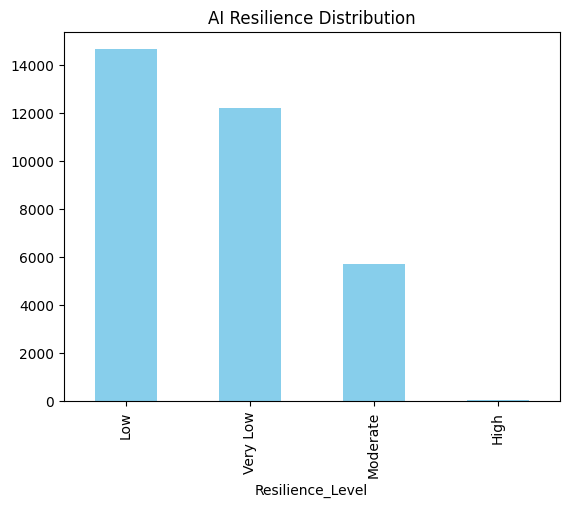

In [99]:
# Show how many students fall into each AI Resilience category
merged["Resilience_Level"].value_counts().plot(kind='bar', color='skyblue', title="AI Resilience Distribution")

<Axes: title={'center': 'Academic Pressure Distribution'}, xlabel='Pressure_Level'>

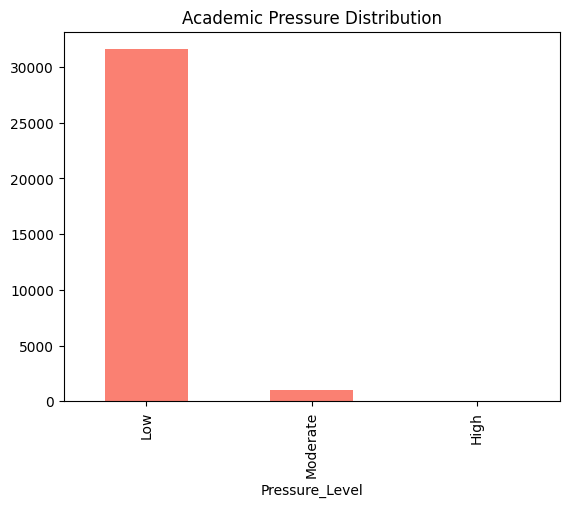

In [100]:
# Show how many students fall into each Academic Pressure category
merged["Pressure_Level"].value_counts().plot(kind='bar', color='salmon', title="Academic Pressure Distribution")

<Axes: title={'center': 'AI Resilience vs Academic Pressure'}, xlabel='AI_Resilience_Score', ylabel='Academic_Pressure_Score'>

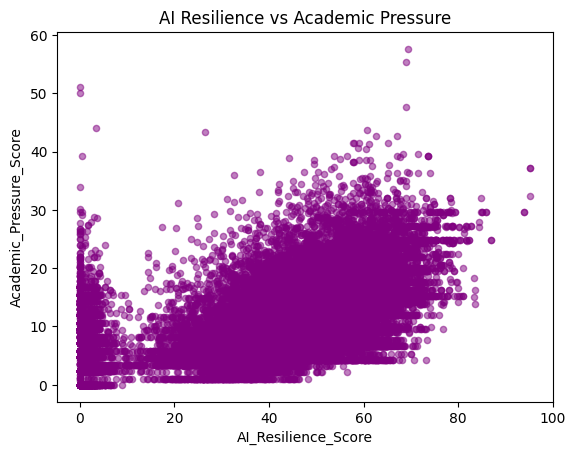

In [101]:
# Shows the relationship between AI Resilience Score and Academic Pressure Score
merged.plot.scatter(x='AI_Resilience_Score', y='Academic_Pressure_Score', alpha=0.5, color='purple', title="AI Resilience vs Academic Pressure")

In [102]:
# Show the corelation between AI Resilience Score and Academic Pressure Score
merged[['AI_Resilience_Score', 'Academic_Pressure_Score']].corr()

,AI_Resilience_Score,Academic_Pressure_Score
AI_Resilience_Score,1.000000,0.600074
Academic_Pressure_Score,0.600074,1.000000


In [103]:
# Save the final dataset with AI Resilience Score and Academic Pressure Score for future analysis
merged.to_csv("student_final_analysis.csv", index=False)
print("Final dataset saved successfully!")

Final dataset saved successfully!
